In [ ]:
# !pip install jupyter notebook
# !pip install tensorflow[and-cuda]
# !pip install optuna

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, MinMaxScaler, Normalizer, RobustScaler, FunctionTransformer
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, r2_score
import tensorflow as tf
from catboost import CatBoostRegressor
import gc
import optuna

import warnings
warnings.filterwarnings('ignore')

I0000 00:00:1778914672.683335   13483 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1778914673.135655   13483 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI AVX_VNNI_INT8 AVX_NE_CONVERT FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1778914674.766327   13483 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [3]:
tf.config.list_physical_devices('GPU')

W0000 00:00:1778914675.824929   13483 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.


[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

In [1]:
!nvidia-smi

Sat May 16 11:57:45 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 595.71.01              Driver Version: 596.36         CUDA Version: 13.2     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 5070 Ti     On  |   00000000:02:00.0  On |                  N/A |
|  0%   45C    P8             23W /  300W |     695MiB /  16303MiB |      8%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

# Данные

Российский рынок недвижимости имеет относительно короткую историю. В советское время вся недвижимость находилась в государственной собственности, люди имели право пользоваться ею только при наличии квартир, выделяемых в зависимости от места работы. В результате возможности для переезда были довольно ограничены. Однако после распада Советского Союза появился российский рынок недвижимости, и москвичи впервые смогли приватизировать, а затем продавать и покупать недвижимость. Сегодня российская недвижимость находится на подъеме. Она предлагает множество захватывающих возможностей и высокую отдачу от образа жизни и инвестиций. Рынок недвижимости находится в фазе роста уже несколько лет, а это означает, что вы все еще можете найти недвижимость по очень привлекательным ценам, но с хорошими шансами на увеличение ее стоимости в будущем.

В датасете 13 полей.

- date — дата публикации объявления;
- time — время публикации объявления;
- geo_lat — широта;
- geo_lon — долгота;
- region — регион России. Всего в стране 85 субъектов.
- building_type — тип фасада. 0 — другое; 1 — панельный; 2 — монолитный; 3 — кирпичный; 4 — блочный; 5 — деревянный.
- object_type — тип квартиры. 1 — вторичный рынок; 2 — новостройка;
- level — этаж квартиры;
- levels — этажность дома;
- rooms — количество жилых комнат. Если значение «-1» — это «квартира-студия»;
- area — общая площадь квартиры;
- kitchen_area — площадь кухни;
- price — цена в рублях.

https://huggingface.co/datasets/daniilakk/Russia_Real_Estate_2018_2021

In [2]:
from datasets import load_dataset # pip install datasets

ds = load_dataset("daniilakk/Russia_Real_Estate_2018_2021")

Осуществлена загрузка структурированного набора данных «Russia_Real_Estate_2018_2021» из репозитория Hugging Face (автор: daniilakk) с использованием библиотеки datasets. Объект ds инициализирован и готов к последующему анализу, включая извлечение признаков объектов недвижимости на территории РФ за указанный период.

In [3]:
df = ds['train'].to_pandas()

df = df[df['price'] > 0]

df = df.sample(1_000_000, random_state=42)

del ds

df

,price,date,time,geo_lat,geo_lon,region,building_type,level,levels,rooms,area,kitchen_area,object_type
1810057,3050000,2019-05-17,10:14:35,55.776405,49.217015,2922,3,12,16,1,40.00,10.00,1
1985039,1012000,2019-06-13,09:50:33,55.030393,83.015545,9654,1,6,10,-1,32.65,2.00,11
3485444,7023000,2020-03-26,11:02:52,54.719284,56.007901,2722,3,32,34,2,72.40,14.30,11
4619679,5300000,2020-10-27,22:35:17,55.769652,37.862254,81,3,5,5,2,43.00,6.00,1
5462830,5435178,2021-04-30,17:53:19,55.571072,37.512361,3,2,7,16,-1,21.00,5.60,11
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3962572,3800000,2020-06-27,09:51:28,55.788622,49.230247,2922,3,8,17,1,52.30,17.90,1
3502574,4090818,2020-03-27,05:46:26,59.825827,30.327501,2661,0,4,15,1,35.12,11.49,11
849164,2585215,2018-12-30,18:58:33,57.604780,39.947050,2604,3,2,12,1,57.87,12.00,1
3291178,2249000,2020-02-16,11:08:01,56.329177,41.320601,5789,3,3,5,1,41.20,11.00,1


Выполнена конвертация обучающей выборки датасета в объект pandas DataFrame. Произведена фильтрация записей, оставлены только наблюдения с положительным значением цены (`price > 0`). Проведён случайный семплированный отбор миллиона наблюдений с фиксацией генератора случайных чисел (`random_state=42`) для обеспечения воспроизводимости результатов. Исходный объект `ds` удалён из оперативной памяти с целью высвобождения вычислительных ресурсов. Результирующий DataFrame `df` содержит 1 000 000 строк.

В данных есть привязка ко времени, мы не можем это игнорировать

В тестовом наборе данные должны идти после обучающего

In [4]:
del df['time']

Привязку ко времени публикации можем убрать, хотя допустимо реализовать на ее основе признак, привязанный ко времени суток публикации: утро, день, вечер, ночь

In [5]:
df['price'] = np.log(df['price'])

Произведено логарифмическое преобразование целевой переменной price с использованием натурального логарифма. Данная операция выполнена для стабилизации дисперсии, приближения распределения к нормальному и уменьшения влияния выбросов в последующем регрессионном анализе.

array([[<Axes: title={'center': 'price'}>,
        <Axes: title={'center': 'geo_lat'}>,
        <Axes: title={'center': 'geo_lon'}>],
       [<Axes: title={'center': 'region'}>,
        <Axes: title={'center': 'building_type'}>,
        <Axes: title={'center': 'level'}>],
       [<Axes: title={'center': 'levels'}>,
        <Axes: title={'center': 'rooms'}>,
        <Axes: title={'center': 'area'}>],
       [<Axes: title={'center': 'kitchen_area'}>,
        <Axes: title={'center': 'object_type'}>, <Axes: >]], dtype=object)

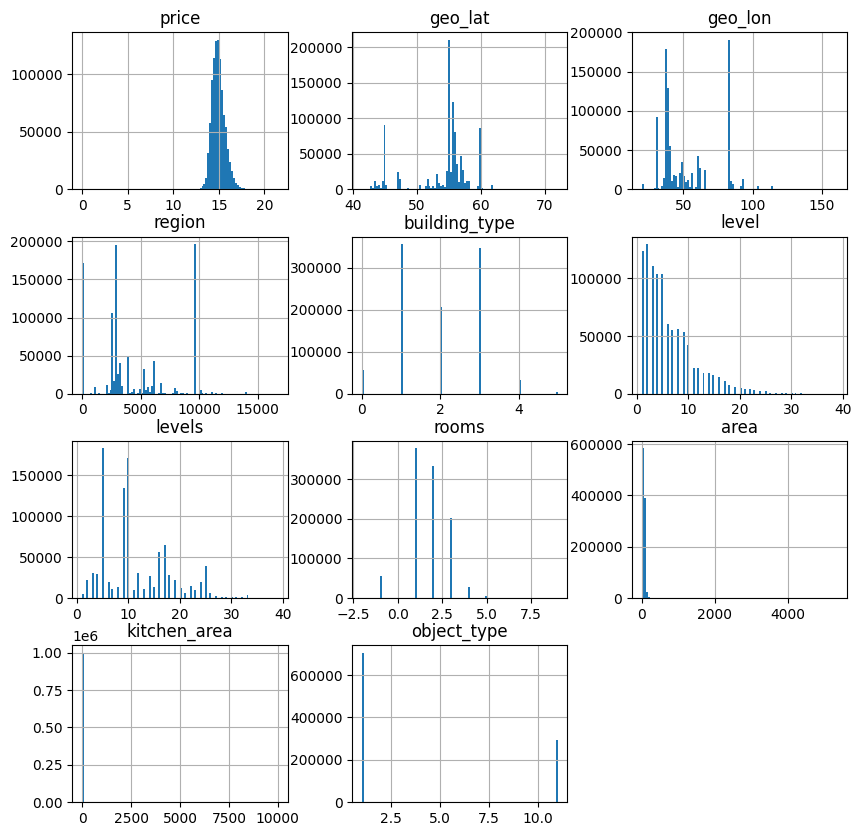

In [6]:
df.hist(bins=100, figsize=[10, 10])

In [7]:
for col in df.columns:
    print(f'В столбце {col} {df[col].nunique()} уникальных значений')

В столбце price 103742 уникальных значений
В столбце date 1004 уникальных значений
В столбце geo_lat 226947 уникальных значений
В столбце geo_lon 227364 уникальных значений
В столбце region 83 уникальных значений
В столбце building_type 6 уникальных значений
В столбце level 39 уникальных значений
В столбце levels 39 уникальных значений
В столбце rooms 11 уникальных значений
В столбце area 9164 уникальных значений
В столбце kitchen_area 3206 уникальных значений
В столбце object_type 2 уникальных значений


Возьмем за категориальные признаки столбцы с кол-вом уникальных значений < 50:
- building_type
- level
- levels
- rooms
- object_type

In [8]:
# Создние категориальных признаков

for col in ['building_type', 'level', 'levels', 'rooms', 'object_type']:

    dummies = pd.get_dummies(df[col], prefix=col, drop_first=True).astype(int)

    df = pd.concat([df, dummies], axis=1)
    del df[col]

Выполнено создание категориальных бинарных признаков методом «one-hot encoding» для колонок `building_type`, `level`, `levels`, `rooms` и `object_type`. Для каждой категориальной переменной сгенерированы фиктивные индикаторные признаки с префиксом, соответствующим исходному имени колонки, с исключением первого уровня мультиколлинеарности (`drop_first=True`). Полученные признаки приведены к целочисленному типу (`int`). Произведена конкатенация с исходным DataFrame и последующее удаление исходных категориальных колонок. В результате все указанные категориальные переменные представлены в бинарном векторном формате, пригодном для использования в параметрических моделях машинного обучения.

# Деление выборки

In [9]:
train_df = df[df['date'] < '2020-01-01']
test_df = df[df['date'] >= '2020-01-01']

print('Соотношение выборок')

train_df.shape, test_df.shape, np.round(len(train_df) / len(df), 2), np.round(len(test_df) / len(df), 2)

Соотношение выборок


((566613, 99), (433387, 99), np.float64(0.57), np.float64(0.43))

Произведено временное разделение выборки на обучающую и тестовую совокупности на основе пороговой даты «2020-01-01». Объекты с датой, предшествующей указанному порогу, отнесены к обучающей выборке (`train_df`), все остальные — к тестовой (`test_df`). Вычислены абсолютные размеры обеих выборок, а также их относительные доли от общего объёма данных с округлением до двух знаков после запятой. Полученные соотношения зафиксированы и могут быть использованы для оценки репрезентативности временной стратификации.

In [10]:
x_train = train_df.drop(columns=['price', 'date']).to_numpy()
x_test = test_df.drop(columns=['price', 'date']).to_numpy()

y_train = train_df['price'].to_numpy()
y_test = test_df['price'].to_numpy()

x_train.shape, x_test.shape, y_train.shape, y_test.shape

((566613, 97), (433387, 97), (566613,), (433387,))

Выполнено формирование матриц признаков и векторов целевых переменных для обучающей и тестовой выборок. Из каждого подмножества данных исключены столбцы `price` (целевая переменная) и `date` (временная метка, не используемая в качестве предиктора). Оставшиеся признаки преобразованы в массивы NumPy (`x_train`, `x_test`). Целевые переменные извлечены отдельно и также конвертированы в NumPy-массивы (`y_train`, `y_test`). Получены размерности результирующих массивов, подтверждающие корректность разделения и отсутствие потерь данных при преобразовании типов.

# Глобальные гиперпараметры

In [11]:
BATCH_SIZE = 512
EPOCHS = 20

Заданы глобальные гиперпараметры процесса обучения: размер мини-батча (`BATCH_SIZE`) установлен в 512 образцов, количество эпох (`EPOCHS`) — 20 итераций полного прохода по обучающей выборке. Указанные параметры определяют конфигурацию процедуры стохастической оптимизации и влияют на скорость сходимости, стабильность градиентного спуска и степень обобщения модели.

# Простейший пайплайн полносвязной сети

In [12]:
# ================================================================
# Препроцессор
# ================================================================

scaler = StandardScaler() # Для нормализации данных, уменьшения шума

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

x_train_scaled.shape, x_test_scaled.shape

((566613, 97), (433387, 97))

Выполнена стандартизация признаковых пространств обучающей и тестовой выборок с использованием `StandardScaler`. Объект масштабирования инициализирован, после чего на обучающих данных вычислены средние значения и стандартные отклонения по каждому признаку (`fit_transform`). Полученные параметры применены для центрирования и нормирования тестовых данных (`transform`). Процедура обеспечивает приведение всех признаков к распределению с нулевым математическим ожиданием и единичной дисперсией, что способствует улучшению сходимости градиентных методов и снижению влияния разнородных масштабов признаков. Размерности преобразованных массивов подтверждают успешность выполнения операции.

In [13]:
# ================================================================
# Создание модели
# ================================================================

tf.keras.backend.clear_session()

model = tf.keras.Sequential([
    tf.keras.layers.Dense(64, activation='relu', input_shape=(x_train.shape[1],)), # Входной слой + первый полносвязный слой
    tf.keras.layers.Dense(32, activation='relu'), # Второй полносвязный слой
    tf.keras.layers.Dense(1, activation='linear') # Выходной слой (регрессия, поэтому активация базовая - linear)
])

# ================================================================
# Компиляция модели
# ================================================================

model.compile(
    optimizer=tf.keras.optimizers.Adam(0.0003),
    loss='mae', # Mean Absolute Error
    metrics=['mse'] # Mean Squared Error
)

# ================================================================
# Вывод структуры модели
# ================================================================

model.summary()

W0000 00:00:1778419409.428497   43770 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
W0000 00:00:1778419409.432173   43770 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
I0000 00:00:1778419409.649885   43770 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13209 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5070 Ti, pci bus id: 0000:02:00.0, compute capability: 12.0a


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         6,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,385 (32.75 KB)

 Trainable params: 8,385 (32.75 KB)

 Non-trainable params: 0 (0.00 B)

Выполнена инициализация архитектуры нейросетевой модели регрессионного типа с использованием последовательного API (`Sequential`) фреймворка TensorFlow/Keras. Произведена очистка ранее накопленного состояния вычислительного графа (`clear_session`). Сконфигурирована трёхслойная архитектура: входной слой с размерностью, соответствующей количеству признаков в обучающей выборке, первый скрытый слой на 64 нейрона с функцией активации ReLU, второй скрытый слой на 32 нейрона с функцией активации ReLU и выходной слой с одним нейроном и линейной функцией активации, что соответствует задаче регрессии. 

Осуществлена компиляция модели с оптимизатором Adam при скорости обучения 0.0003. В качестве функции потерь выбрана средняя абсолютная ошибка (MAE), метрикой качества определена среднеквадратичная ошибка (MSE). Выведена сводная информация об архитектуре модели, включая количество обучаемых параметров по каждому слою и общий объём обучаемых весов.

In [14]:
%%time

# ================================================================
# Обучение модели
# ================================================================

history = model.fit(
    x_train_scaled, 
    y_train,
    validation_split=0.2,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1
)

Epoch 1/20


I0000 00:00:1778419410.996365   43914 service.cc:153] XLA service 0x74ae5c041520 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778419410.996386   43914 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 5070 Ti, Compute Capability 12.0a (Driver: 13.2.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.19.0)
I0000 00:00:1778419411.007563   43914 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1778419411.077660   43914 cuda_dnn.cc:461] Loaded cuDNN version 91900
I0000 00:00:1778419411.085021   43914 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1270__.9


 86/886 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 14.2683 - mse: 204.8757

I0000 00:00:1778419412.183736   43914 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


861/886 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7.2250 - mse: 87.8386

I0000 00:00:1778419413.721327   43916 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1270__.9


886/886 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 3.1391 - mse: 32.8805 - val_loss: 0.5144 - val_mse: 2.3514
Epoch 2/20
886/886 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.4160 - mse: 2.0406 - val_loss: 0.3665 - val_mse: 0.8160
Epoch 3/20
886/886 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.3407 - mse: 1.1194 - val_loss: 0.3280 - val_mse: 0.4919
Epoch 4/20
886/886 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.3141 - mse: 0.7560 - val_loss: 0.3081 - val_mse: 0.3473
Epoch 5/20
886/886 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.2999 - mse: 0.5154 - val_loss: 0.2998 - val_mse: 0.2737
Epoch 6/20
886/886 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.2915 - mse: 0.3890 - val_loss: 0.2922 - val_mse: 0.2448
Epoch 7/20
886/886 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.2855 - mse: 0.3283 - val_loss: 0.2867 - val_mse: 0.2311
Epoch 8/20
886/886 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.2812 - mse: 0.2770 - val_loss: 0.2828 - val_mse: 0.2229
Epoch 9/20
886/886 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.2779

Зафиксировано время выполнения процедуры обучения нейросетевой модели. Инициирован процесс обучения с использованием масштабированных признаков обучающей выборки и соответствующих целевых значений. Применена внутренняя валидация с выделением 20% обучающих данных в качестве валидационной выборки (`validation_split=0.2`). Обучение проведено в течение 20 эпох с размером мини-батча 512 образцов. Вывод процесса обучения выполнен в режиме подробного логирования (`verbose=1`). Объект `history` сохранён для последующего анализа динамики функций потерь и метрик на обучающей и валидационной выборках.

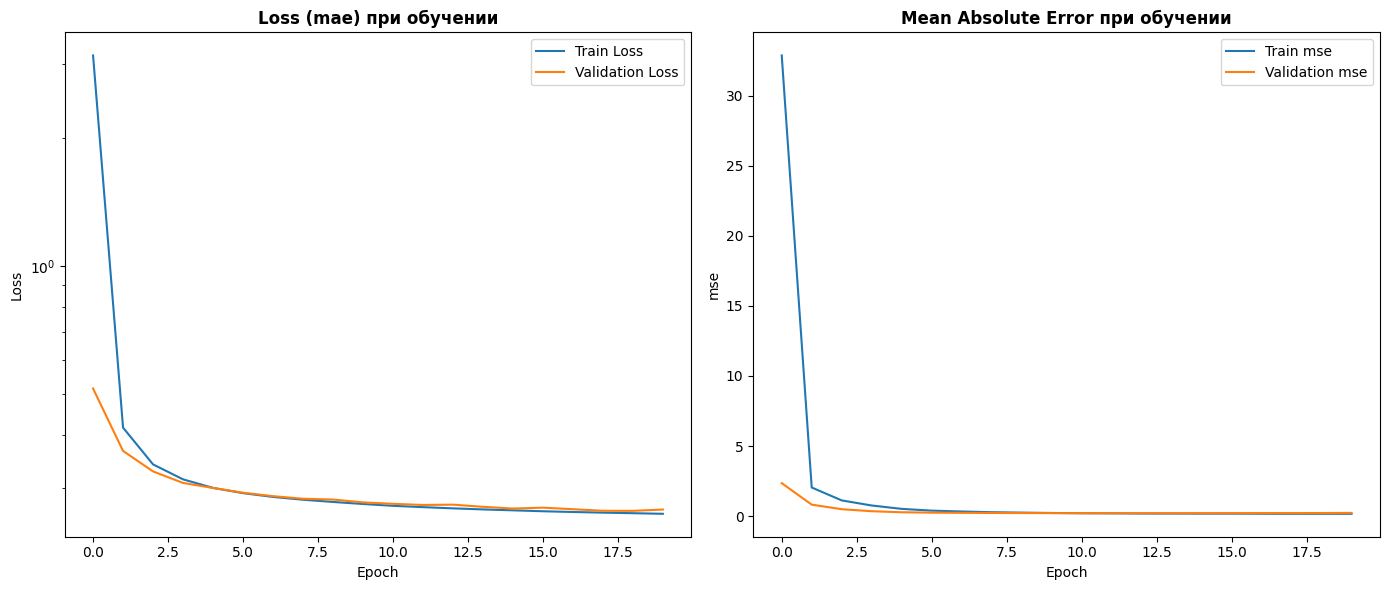

In [15]:
# ================================================================
# Визуализация процесса обучения
# ================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ================================================================
# График потерь (Loss)
# ================================================================

axes[0].plot(history.history['loss'], label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Validation Loss')
axes[0].set_title('Loss (mae) при обучении', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].set_yscale('log')  # Логарифмическая шкала

# ================================================================
# График MSE
# ================================================================

axes[1].plot(history.history['mse'], label='Train mse')
axes[1].plot(history.history['val_mse'], label='Validation mse')
axes[1].set_title('MSE при обучении', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('mse')
axes[1].legend()

plt.tight_layout()
plt.show()

In [16]:
# ================================================================
# Прогноз на тестовой выборке
# ================================================================

y_pred = model.predict(x_test_scaled, verbose=1, batch_size=BATCH_SIZE)

y_pred

847/847 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


array([[15.310589],
       [14.914833],
       [14.783394],
       ...,
       [15.164847],
       [15.186257],
       [14.323021]], shape=(433387, 1), dtype=float32)

Выполнен прогноз целевой переменной на тестовой выборке с использованием обученной модели. Метод `predict` применён к масштабированным признакам тестового набора (`x_test_scaled`) с размером батча 512 образцов и включённым выводом прогресса (`verbose=1`). Получен массив предсказанных значений `y_pred` размерности, соответствующей количеству образцов в тестовой выборке (по одному предсказанию на объект). Предсказанные значения представлены в логарифмическом масштабе, что соответствует ранее выполненному преобразованию целевой переменной. Результат выведен для визуального контроля и последующего обратного преобразования при необходимости интерпретации в исходном ценовом масштабе.

In [17]:
# ================================================================
# Метрики ошибок на тестовой выборке
# ================================================================

print('mean_absolute_error:', np.round(mean_absolute_error(y_test, y_pred), 4))
print('mean_absolute_percentage_error:', np.round(mean_absolute_percentage_error(y_test, y_pred), 4))
print('r2_score:', np.round(r2_score(y_test, y_pred), 4))

mean_absolute_error: 0.3378
mean_absolute_percentage_error: 143647042208.3434
r2_score: 0.4932


Вычислены ключевые метрики качества регрессионной модели на тестовой выборке путём сравнения истинных (`y_test`) и предсказанных (`y_pred`) значений целевой переменной. Средняя абсолютная ошибка (MAE) отражает среднюю величину отклонения предсказаний от фактических значений в натуральных единицах логарифмированного масштаба. Средняя абсолютная процентная ошибка (MAPE) характеризует относительную точность прогнозов в процентном выражении. Коэффициент детерминации (R²) показывает долю дисперсии целевой переменной, объясняемую моделью, относительно её полной дисперсии. Все метрики округлены до четырёх знаков после запятой. Полученные значения позволяют оценить предсказательную способность модели и её пригодность для решения поставленной регрессионной задачи.

<Axes: >

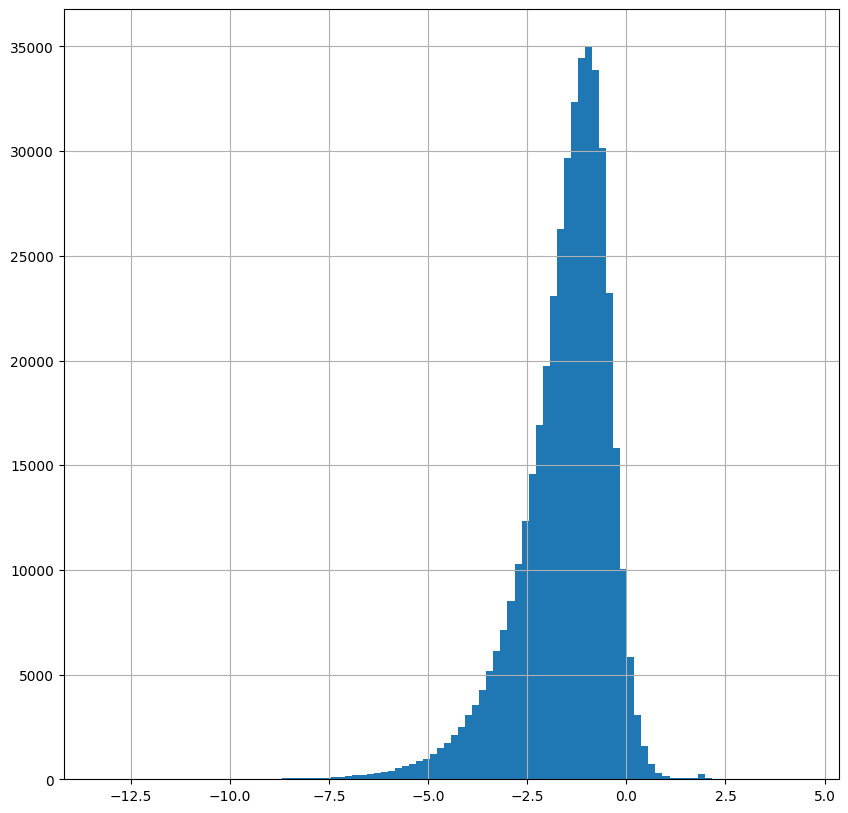

In [18]:
# ================================================================
# Распределение ошибок
# ================================================================

test_df['price_predicted'] = y_pred

test_df['errors'] = test_df['price'] - test_df['price_predicted']

np.log(abs(test_df['errors'])).hist(bins=100, figsize=[10, 10])

In [19]:
# ================================================================
# Примеры прогнозов
# ================================================================

test_df[['price', 'date', 'price_predicted']].tail(10)

,price,date,price_predicted
3974659,14.334304,2020-06-29,14.073260
3797233,14.630875,2020-05-28,14.481583
4034714,15.404746,2020-07-06,15.300749
5429814,14.699278,2021-04-28,14.620552
4167548,16.118096,2020-07-28,16.285341
3779754,15.640060,2020-05-25,15.457668
4250894,13.353475,2020-08-07,14.398942
3962572,15.150512,2020-06-27,15.164847
3502574,15.224256,2020-03-27,15.186257
3291178,14.625996,2020-02-16,14.323021


# Градиентный бустинг

In [20]:
tf.keras.backend.clear_session()

In [21]:
%%time

# ================================================================
# CatBoostRegressor
# ================================================================

model = CatBoostRegressor(
    random_state=42, 
    task_type='GPU', 
    verbose=False
)

model.fit(x_train, y_train)

y_pred = model.predict(x_test)

CPU times: user 10.3 s, sys: 3.1 s, total: 13.4 s
Wall time: 8.01 s


Зафиксировано время выполнения процедуры обучения и предсказания с использованием ансамблевого метода градиентного бустинга на основе симметричных деревьев решений — `CatBoostRegressor`. Инициализирована модель с фиксированным генератором случайных чисел (`random_state=42`), аппаратным ускорителем GPU (`task_type='GPU'`) и отключённым выводом процесса обучения (`verbose=False`). Произведено обучение модели на исходных (немасштабированных) признаковых матрицах `x_train` и целевых значениях `y_train` (логарифмированная цена). CatBoost устойчив к различным масштабам признаков вследствие использования древовидных структур, поэтому предварительная стандартизация не применялась. Выполнен прогноз на тестовой выборке (`x_test`) с получением массива предсказанных значений `y_pred`. Общее время выполнения операции включает как процесс построения ансамбля, так и фазу инференса.

In [22]:
# ================================================================
# Метрики ошибок на тестовой выборке
# ================================================================

print('mean_absolute_error:', np.round(mean_absolute_error(y_test, y_pred), 4))
print('mean_absolute_percentage_error:', np.round(mean_absolute_percentage_error(y_test, y_pred), 4))
print('r2_score:', np.round(r2_score(y_test, y_pred), 4))

mean_absolute_error: 0.2332
mean_absolute_percentage_error: 151067943141.9633
r2_score: 0.7662


**Возьмем метрики бустинга за референтные в данной задаче**

# Оптимизация гиперпараметров полносвязной сети, валидация/тюнинг модели

## Функция модели

Функция построения полносвязной нейронной сети (FCNN)
В данном блоке реализуется функция fcnn_model для создания, компиляции и обучения полносвязной нейронной сети регрессионного типа.

Основные возможности:
- Гибкая архитектура с настраиваемым количеством слоёв и нейронов

- Batch Normalization для стабилизации обучения и ускорения сходимости

- Dropout для регуляризации и борьбы с переобучением

- Early Stopping для автоматического предотвращения переобучения

- Поддержка нескольких функций потерь (MAE, MSE, Huber)

- Возможность использования валидационной выборки

In [23]:
def fcnn_model(
    x_train,
    y_train,
    x_val=None,
    y_val=None,
    n_units=64,
    num_layers=2,
    learning_rate=3e-4,
    batch_size=64,
    dropout=0.2,
    batch_norm=True, 
    epochs=100,
    patience=5,
    loss='mae',
    verbose=1
):
    """
    Построение и обучение полносвязной нейронной сети для задач регрессии.
    
    Параметры:
    ----------
    x_train : array-like
        Обучающие признаки (форма: [n_samples, n_features])
    y_train : array-like
        Обучающие целевые значения (форма: [n_samples])
    x_val : array-like, optional
        Валидационные признаки
    y_val : array-like, optional
        Валидационные целевые значения
    n_units : int
        Количество нейронов в каждом скрытом слое
    num_layers : int
        Общее количество скрытых слоёв
    learning_rate : float
        Скорость обучения для оптимизатора Adam
    batch_size : int
        Размер батча при обучении
    dropout : float
        Вероятность дропаута (0.0 - 1.0). 0 означает отсутствие Dropout слоёв
    batch_norm : bool
        Включает/выключает Batch Normalization после каждого скрытого слоя
    epochs : int
        Максимальное количество эпох обучения
    patience : int
        Количество эпох без улучшения для Early Stopping
    loss : str
        Функция потерь: 'mae', 'mse', 'huber'
    verbose : int
        Детализация вывода (0 - нет вывода, 1 - с прогресс-баром, 2 - одна строка на эпоху)
    
    Возвращает:
    ----------
    model : tf.keras.Model
        Обученная модель
    history : dict
        История обучения (потери и метрики по эпохам)
    """
    
    # ================================================================
    # Создание модели (циклом)
    # ================================================================
    
    # Инициализация Sequential модели
    model = tf.keras.Sequential()
    
    # Входной слой + первый полносвязный слой
    model.add(tf.keras.layers.Dense(
        n_units,
        use_bias=True,           # Смещение будет добавлено до BatchNorm (BatchNorm свой bias добавит)
        input_shape=(x_train.shape[1],)
    ))
    
    # Batch Normalization (если включена)
    if batch_norm:
        model.add(tf.keras.layers.BatchNormalization())
    
    # Активация
    model.add(tf.keras.layers.Activation('relu'))
    
    # Dropout
    if dropout > 0:
        model.add(tf.keras.layers.Dropout(dropout))
    
    # Цикл для создания дополнительных скрытых слоёв (num_layers - 1)
    for i in range(num_layers - 1):
        # Полносвязный слой
        model.add(tf.keras.layers.Dense(n_units, use_bias=not batch_norm))
        
        # Batch Normalization (если включена)
        if batch_norm:
            model.add(tf.keras.layers.BatchNormalization())
        
        # Активация ReLU
        model.add(tf.keras.layers.Activation('relu'))
        
        # Dropout (если задан)
        if dropout > 0:
            model.add(tf.keras.layers.Dropout(dropout))
    
    # Выходной слой (регрессия -> линейная активация)
    model.add(tf.keras.layers.Dense(1, activation='linear'))
    
    # ================================================================
    # Компиляция модели
    # ================================================================
    
    # Выбор функции потерь
    if loss == 'mae':
        loss_fn = 'mae'
    elif loss == 'mse':
        loss_fn = 'mse'
    elif loss == 'huber':
        loss_fn = tf.keras.losses.Huber(delta=1.0)  # delta - порог для перехода между MAE и MSE
    else:
        loss_fn = 'mae'  # по умолчанию MAE
    
    # Компиляция с оптимизатором Adam
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss=loss_fn,
        metrics=['mae', 'mse']  # отслеживаем обе метрики для контроля качества
    )
    
    # ================================================================
    # Callbacks (Early Stopping)
    # ================================================================
    
    callbacks = [
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss' if x_val is not None else 'loss',
            patience=patience,
            restore_best_weights=True,   # восстанавливаем веса лучшей эпохи
            verbose=verbose if verbose > 0 else 0
        )
    ]
    
    # ================================================================
    # Обучение модели
    # ================================================================
    
    history = model.fit(
        x_train,
        y_train,
        validation_data=(x_val, y_val) if x_val is not None else None,
        epochs=epochs,
        batch_size=batch_size,
        callbacks=callbacks,
        verbose=verbose
    )
    
    # ================================================================
    # Возврат модели и истории обучения
    # ================================================================
    
    return model, history.history

Разработана параметризированная функция `fcnn_model` для построения и обучения полносвязной нейронной сети регрессионного типа. Функция реализует модульную архитектуру со следующими возможностями:

- **Гибкая конфигурация топологии**: задаётся количество нейронов в скрытых слоях (`n_units`) и общее количество скрытых слоёв (`num_layers`). Первый слой создаётся с явным указанием входной размерности, последующие — циклически.
- **Регуляризация**: поддерживается dropout с настраиваемой вероятностью отключения нейронов.
- **Нормализация активаций**: опциональное включение слоёв Batch Normalization после каждого скрытого слоя.
- **Функции потерь**: доступны MAE, MSE и Huber loss (с дельтой 1.0).
- **Ранняя остановка**: реализована через callback EarlyStopping с контролем валидационной или обучающей потери, восстановлением наилучших весов и настраиваемым терпением (`patience`).
- **Валидация**: поддерживается передача отдельной валидационной выборки для мониторинга качества в процессе обучения.

Функция возвращает обученную модель и словарь истории обучения, содержащий динамику функции потерь и метрик (MAE, MSE) по эпохам. Данная реализация обеспечивает воспроизводимость экспериментов и системный подход к подбору гиперпараметров.

## Разделение выборке с выделение валидационной части

In [24]:
train_temp_df = train_df[train_df['date'] < '2019-06-01']
test_temp_df = train_df[(train_df['date'] >= '2019-06-01') & (df['date'] < '2020-01-01')]

x_train_temp = train_temp_df.drop(columns=['price', 'date']).to_numpy()
x_test_temp = test_temp_df.drop(columns=['price', 'date']).to_numpy()

y_train_temp = train_temp_df['price'].to_numpy()
y_test_temp = test_temp_df['price'].to_numpy()

x_train_temp.shape, x_test_temp.shape, y_train_temp.shape, y_test_temp.shape

((348371, 97), (218242, 97), (348371,), (218242,))

Выполнено временное стратифицированное разделение обучающей выборки для целей валидации архитектуры и гиперпараметров. Из исходной обучающей совокупности (`train_df`) выделены два непересекающихся подмножества на основе пороговых дат: обучающий поднабор (`train_temp_df`) включает объекты с датой ранее «2019-06-01», валидационный поднабор (`test_temp_df`) — объекты, дата которых находится в интервале от «2019-06-01» включительно до «2020-01-01» (исключая правую границу). 

Для каждого из указанных подмножеств сформированы матрицы признаков (`x_train_temp`, `x_test_temp`) путём исключения колонок `price` и `date`, а также векторы целевых переменных (`y_train_temp`, `y_test_temp`). Произведено преобразование в массивы NumPy. Полученные размерности подтверждают корректность временного разделения и готовность данных для обучения и валидации модели на временном срезе, отличном от итогового тестового периода (после 2020-01-01).

## Подбор препроцессора

Сначала подбираем препроцессор на стандартных гиперпараметрах, затем с оптимальным препроцессором будем проводить тюнинг модели

In [25]:
preprocessor_list = ['StandardScaler', 'MinMaxScaler', 'RobustScaler', 'Normalizer', None]

len(preprocessor_list)

5

Сформирован перечень из пяти возможных типов препроцессоров для масштабирования признакового пространства, подлежащих сравнительной оценке: `StandardScaler` (стандартизация с центрированием к нулевому среднему и единичному отклонению), `MinMaxScaler` (приведение к заданному диапазону, по умолчанию [0, 1]), `RobustScaler` (устойчивое масштабирование на основе квартилей, резистентное к выбросам), `Normalizer` (поэлементная нормализация каждого образца к единичной норме), а также вариант без масштабирования (`None`). Общее количество подлежащих тестированию методов препроцессинга — пять.

In [26]:
results = pd.DataFrame()
i = 0

for preprocessor in preprocessor_list:

    if preprocessor == 'StandardScaler':
        scaler = StandardScaler()

    if preprocessor == 'MinMaxScaler':
        scaler = MinMaxScaler()

    if preprocessor == 'Normalizer':
        scaler = Normalizer()

    if preprocessor == 'RobustScaler':
        scaler = RobustScaler()

    if preprocessor == None:
        scaler = FunctionTransformer()

    x_train_temp_scaled = scaler.fit_transform(x_train_temp)
    x_test_temp_scaled = scaler.transform(x_test_temp)

    model, history = fcnn_model(
        x_train=x_train_temp_scaled,
        y_train=y_train_temp,
        x_val=x_test_temp_scaled,
        y_val=y_test_temp,
        n_units=64,
        num_layers=2,
        learning_rate=3e-4,
        batch_size=BATCH_SIZE,
        dropout=0,
        batch_norm=True, 
        epochs=EPOCHS,
        patience=5,
        loss='mae',
        verbose=1
    )
    
    y_pred = model.predict(x_test_temp_scaled, batch_size=BATCH_SIZE, verbose=1)

    score = mean_absolute_error(y_test_temp, y_pred)

    iteration_df = pd.DataFrame({
        'preprocessor': [preprocessor],
        'score': [score],
    })

    results = pd.concat([results, iteration_df], axis=0, ignore_index=True)

    i += 1
    print('Combination >>>>', i)

    del (
        x_train_temp_scaled,
        x_test_temp_scaled,
        model,
        history,
        y_pred,
        score,
        scaler
    )

    gc.collect()
    tf.keras.backend.clear_session()

results = results.sort_values('score', ascending=True)

Epoch 1/20


I0000 00:00:1778419490.414931   43904 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_98800__.22


671/681 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 12.8636 - mae: 12.8636 - mse: 171.1774

I0000 00:00:1778419493.357160   43909 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_98800__.22


681/681 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - loss: 10.4778 - mae: 10.4778 - mse: 120.2518 - val_loss: 5.2976 - val_mae: 5.2976 - val_mse: 33.9662
Epoch 2/20
681/681 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 1.3153 - mae: 1.3153 - mse: 5.1048 - val_loss: 0.5084 - val_mae: 0.5084 - val_mse: 0.8864
Epoch 3/20
681/681 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.4013 - mae: 0.4013 - mse: 0.3499 - val_loss: 0.3951 - val_mae: 0.3951 - val_mse: 0.5048
Epoch 4/20
681/681 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.3675 - mae: 0.3675 - mse: 0.2779 - val_loss: 0.3606 - val_mae: 0.3606 - val_mse: 0.3703
Epoch 5/20
681/681 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.3508 - mae: 0.3508 - mse: 0.2502 - val_loss: 0.3359 - val_mae: 0.3359 - val_mse: 0.3130
Epoch 6/20
681/681 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.3382 - mae: 0.3382 - mse: 0.2307 - val_loss: 0.3323 - val_mae: 0.3323 - val_mse: 0.2780
Epoch 7/20
681/681 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.3261 - mae: 0.3261 - mse: 0.2158 - val_loss:

...

681/681 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 10.0072 - mae: 10.0072 - mse: 109.7134 - val_loss: 5.4285 - val_mae: 5.4285 - val_mse: 31.4577
Epoch 2/20
681/681 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 1.3854 - mae: 1.3854 - mse: 4.5826 - val_loss: 0.7843 - val_mae: 0.7843 - val_mse: 1.0349
Epoch 3/20
681/681 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.4188 - mae: 0.4188 - mse: 0.3160 - val_loss: 1.9627 - val_mae: 1.9627 - val_mse: 4.7758
Epoch 4/20
681/681 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.3563 - mae: 0.3563 - mse: 0.2420 - val_loss: 3.1853 - val_mae: 3.1853 - val_mse: 12.4321
Epoch 5/20
681/681 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.3361 - mae: 0.3361 - mse: 0.2186 - val_loss: 1.6923 - val_mae: 1.6923 - val_mse: 3.4796
Epoch 6/20
681/681 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.3177 - mae: 0.3177 - mse: 0.1982 - val_loss: 0.8723 - val_mae: 0.8723 - val_mse: 1.0781
Epoch 7/20
681/681 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.3076 - mae: 0.3076 - mse: 0.1878 - val_loss

I0000 00:00:1778419642.142863   43914 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_457050__.22


659/681 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 12.9417 - mae: 12.9417 - mse: 173.4990

I0000 00:00:1778419644.005025   43914 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_457050__.22


681/681 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 10.6769 - mae: 10.6769 - mse: 124.2038 - val_loss: 7.9519 - val_mae: 7.9519 - val_mse: 64.6797
Epoch 2/20
681/681 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 1.7600 - mae: 1.7600 - mse: 7.5857 - val_loss: 1.5466 - val_mae: 1.5466 - val_mse: 3.3112
Epoch 3/20
681/681 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.3796 - mae: 0.3796 - mse: 0.3213 - val_loss: 0.6200 - val_mae: 0.6200 - val_mse: 0.6119
Epoch 4/20
681/681 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.3267 - mae: 0.3267 - mse: 0.2325 - val_loss: 0.3663 - val_mae: 0.3663 - val_mse: 0.2587
Epoch 5/20
681/681 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.3143 - mae: 0.3143 - mse: 0.2119 - val_loss: 0.4726 - val_mae: 0.4726 - val_mse: 0.3672
Epoch 6/20
681/681 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.3042 - mae: 0.3042 - mse: 0.1976 - val_loss: 0.6493 - val_mae: 0.6493 - val_mse: 0.7084
Epoch 7/20
681/681 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.2957 - mae: 0.2957 - mse: 0.1874 - val_loss:

Проведён систематический сравнительный анализ влияния различных методов препроцессинга признаков на качество прогнозирования полносвязной нейронной сети, регламентированный следующим экспериментальным протоколом:

1. **Итеративный перебор препроцессоров**: выполнено пять итераций, каждая из которых соответствует одному из тестируемых методов масштабирования (`StandardScaler`, `MinMaxScaler`, `RobustScaler`, `Normalizer`) либо отсутствию масштабирования (`FunctionTransformer` в качестве пассивного преобразователя).

2. **Цикл обработки данных**: на каждой итерации произведено масштабирование валидационного признакового подмножества (`x_train_temp`) с вычислением параметров преобразования (`fit_transform`) и последующим применением тех же параметров к тестовому подмножеству внутри валидационного среза (`x_test_temp`).

3. **Обучение модели**: для каждого варианта препроцессинга построена и обучена полносвязная нейронная сеть посредством функции `fcnn_model` с фиксированной архитектурой (64 нейрона, 2 слоя, Batch Normalization, скорость обучения 3e-4, размер батча 512, 20 эпох) на масштабированных данных.

4. **Оценка качества**: для каждой обученной модели выполнен прогноз на валидационном подмножестве (`x_test_temp_scaled`) и рассчитана средняя абсолютная ошибка (MAE) между истинными (`y_test_temp`) и предсказанными значениями.

5. **Агрегация результатов**: результаты каждой итерации сохранены в DataFrame с колонками «препроцессор» и «значение ошибки», после чего выполнена конкатенация в общую таблицу `results`.

6. **Управление памятью**: после завершения каждой итерации произведено удаление временных объектов (`x_train_temp_scaled`, `x_test_temp_scaled`, модель, история обучения, прогнозы, ошибка, скейлер), инициирован сборщик мусора (`gc.collect()`) и очищено состояние вычислительного графа TensorFlow (`clear_session`).

7. **Ранжирование**: итоговая таблица отсортирована по возрастанию ошибки, что позволяет идентифицировать препроцессор, обеспечивающий минимальную прогностическую ошибку в рамках заданной конфигурации модели.

In [27]:
results

,preprocessor,score
2,RobustScaler,0.259269
1,MinMaxScaler,0.272755
0,StandardScaler,0.281669
4,None,0.366339
3,Normalizer,0.784328


## Тюнинг гиперпараметров через Optuna

**Optuna** — это фреймворк для автоматической оптимизации гиперпараметров моделей машинного обучения. Она позволяет эффективно искать наилучшие комбинации параметров, минимизируя или максимизируя заданную целевую функцию (например, ошибку модели).

Ключевые особенности Optuna:
- **Поиск с использованием байесовской оптимизации** (TPE-алгоритм)
- **Автоматическое управление историей экспериментов**
- **Возможность распараллеливания**
- **Поддержка различных типов гиперпараметров** (категориальные, целочисленные, вещественные)

In [28]:
# ================================================================
# Препроцессор
# ================================================================

scaler = RobustScaler() # RobustScaler отобран в предыдщем пункте

x_train_temp_scaled = scaler.fit_transform(x_train_temp)
x_test_temp_scaled = scaler.transform(x_test_temp)

In [29]:
def objective(trial):

    n_units = trial.suggest_int('n_units', 32, 512, step=32)
    num_layers = trial.suggest_int('num_layers', 1, 5, step=1)
    dropout = trial.suggest_float('dropout', 0, 0.5, step=0.1)
    loss = trial.suggest_categorical('loss', ['mse', 'mae', 'huber'])
    learning_rate = trial.suggest_float('learning_rate', 1e-5, 1e-3, log=True)
    batch_norm = trial.suggest_categorical('batch_norm', [True, False])

    model, history = fcnn_model(
        x_train=x_train_temp_scaled,
        y_train=y_train_temp,
        x_val=x_test_temp_scaled,
        y_val=y_test_temp,
        n_units=n_units,
        num_layers=num_layers,
        learning_rate=learning_rate,
        batch_size=BATCH_SIZE,
        dropout=dropout,
        batch_norm=batch_norm, 
        epochs=EPOCHS,
        patience=5,
        loss=loss,
        verbose=0
    )

    y_pred = model.predict(x_test_temp_scaled, batch_size=BATCH_SIZE, verbose=0)

    score = mean_absolute_error(y_test_temp, y_pred)

    del model, history, y_pred

    gc.collect()
    tf.keras.backend.clear_session()

    return score

Определена целевая функция `objective` для проведения байесовской оптимизации гиперпараметров полносвязной нейронной сети с использованием фреймворка Optuna. Функция реализует следующий алгоритм:

1. **Семплирование гиперпараметров** из заданных поисковых пространств:
   - `n_units` (32–512, шаг 32) — количество нейронов в скрытых слоях
   - `num_layers` (1–5) — число скрытых слоёв
   - `dropout` (0–0.5, шаг 0.1) — вероятность дропаута
   - `loss` (категориальный: MSE, MAE, Huber) — функция потерь
   - `learning_rate` (1e-5 – 1e-3, логарифмическая шкала) — скорость обучения оптимизатора
   - `batch_norm` (бинарный: True/False) — наличие слоёв пакетной нормализации

2. **Обучение модели**: вызов функции `fcnn_model` с зафиксированными валидационными данными (`x_train_temp_scaled`, `y_train_temp`, `x_test_temp_scaled`, `y_test_temp`) и подобранными гиперпараметрами. Обучение выполняется без вывода прогресса (`verbose=0`).

3. **Оценка качества**: расчёт прогноза на валидационном подмножестве с последующим вычислением средней абсолютной ошибки (MAE) между истинными (`y_test_temp`) и предсказанными значениями.

4. **Освобождение ресурсов**: удаление временных объектов (модель, история обучения, прогнозы), принудительный сбор мусора и очистка состояния вычислительного графа TensorFlow для предотвращения накопления памяти при последовательных итерациях оптимизации.

5. **Возврат значения ошибки**: MAE выступает в качестве минимизируемой метрики (чем меньше значение, тем лучше конфигурация гиперпараметров).

Функция предназначена для передачи в объект `study.optimize()` с целью поиска оптимальной комбинации гиперпараметров, минимизирующей прогностическую ошибку модели.

In [30]:
sampler = optuna.samplers.TPESampler(
    n_startup_trials=5,
    multivariate=True,
    group=True,
    constant_liar=False
)

study = optuna.create_study(direction='minimize', sampler=sampler)

[I 2026-05-10 18:27:46,814] A new study created in memory with name: no-name-4d51b250-197e-4e80-a50d-4d9efcb45858


Сконфигурирован объект байесовской оптимизации гиперпараметров на основе алгоритма TPE (Tree-structured Parzen Estimator) с использованием библиотеки Optuna.

**Настройки сэмплера `TPESampler`**:
- `n_startup_trials=5` — количество случайных итераций до начала работы байесовского метода для начального заполнения пространства гиперпараметров
- `multivariate=True` — включение многомерного TPE-сэмплера, учитывающего корреляционные зависимости между гиперпараметрами при построении вероятностных моделей
- `group=True` — группировка предложенных гиперпараметров для совместного рассмотрения в рамках одного испытания
- `constant_liar=False` — отключение стратегии «постоянного лжеца», используемой при параллельной оптимизации

**Создание исследования `study`**:
- `direction='minimize'` — направление оптимизации задано на минимизацию целевой метрики (MAE ошибки)
- `sampler=sampler` — исследованию передан сконфигурированный TPE-сэмплер

Объект `study` готов к запуску оптимизации путём вызова метода `study.optimize(objective, n_trials=N)` для поиска оптимальной конфигурации гиперпараметров нейросетевой модели.

In [31]:
study.optimize(
    objective,
    n_trials=50,
    show_progress_bar=True,
    gc_after_trial=True,
    n_jobs=1
)

  0%|          | 0/50 [00:00<?, ?it/s]

I0000 00:00:1778419668.148737   43914 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_513681__.19
I0000 00:00:1778419668.731104   53173 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_24', 4 bytes spill stores, 4 bytes spill loads

I0000 00:00:1778419672.632673   43916 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_513681__.19
I0000 00:00:1778419672.823799   53298 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_46', 16 bytes spill stores, 16 bytes spill loads

I0000 00:00:1778419673.557928   53287 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_1_10', 8 bytes spill stores, 8 bytes spill loads

I0000 00:00:1778419673.567684   53298 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in functio

[I 2026-05-10 18:28:10,809] Trial 0 finished with value: 4.057227353169498 and parameters: {'n_units': 320, 'num_layers': 5, 'dropout': 0.5, 'loss': 'huber', 'learning_rate': 1.672089514251227e-05, 'batch_norm': False}. Best is trial 0 with value: 4.057227353169498.


I0000 00:00:1778419691.611100   43909 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_551902__.11
I0000 00:00:1778419691.890872   54113 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_8', 4 bytes spill stores, 4 bytes spill loads

I0000 00:00:1778419694.243867   43904 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_551902__.11
I0000 00:00:1778419694.521539   54184 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_14', 16 bytes spill stores, 16 bytes spill loads



[I 2026-05-10 18:29:01,324] Trial 1 finished with value: 0.2701359245756326 and parameters: {'n_units': 448, 'num_layers': 1, 'dropout': 0.4, 'loss': 'mae', 'learning_rate': 0.0002922253000803753, 'batch_norm': False}. Best is trial 1 with value: 0.2701359245756326.


...

[I 2026-05-10 19:04:55,472] Trial 47 finished with value: 0.2531701651838134 and parameters: {'n_units': 192, 'num_layers': 5, 'dropout': 0.0, 'loss': 'huber', 'learning_rate': 6.192385076868071e-05, 'batch_norm': True}. Best is trial 24 with value: 0.21020751392454518.


I0000 00:00:1778421897.260351   43904 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_5445356__.19
I0000 00:00:1778421900.433416   43904 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_5445356__.19


[I 2026-05-10 19:05:48,648] Trial 48 finished with value: 0.7414229626172429 and parameters: {'n_units': 480, 'num_layers': 5, 'dropout': 0.2, 'loss': 'mse', 'learning_rate': 1.239537433037352e-05, 'batch_norm': False}. Best is trial 24 with value: 0.21020751392454518.


I0000 00:00:1778421950.100077   43915 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_5562507__.12
I0000 00:00:1778421952.622779   43904 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_5562507__.12


[I 2026-05-10 19:06:40,662] Trial 49 finished with value: 0.23351692450833697 and parameters: {'n_units': 512, 'num_layers': 3, 'dropout': 0.0, 'loss': 'huber', 'learning_rate': 0.00011237135671764816, 'batch_norm': False}. Best is trial 24 with value: 0.21020751392454518.


Запущена процедура байесовской оптимизации гиперпараметров с использованием TPE-сэмплера в рамках 50 испытаний (`n_trials=50`). Визуализация прогресса включена (`show_progress_bar=True`), что обеспечивает отображение индикатора выполнения для мониторинга хода оптимизации. Освобождение памяти после каждого испытания активировано (`gc_after_trial=True`). Вычисления производятся последовательно в одном процессе (`n_jobs=1`). В ходе выполнения происходит многократный вызов целевой функции `objective` с различными комбинациями гиперпараметров, оценивается валидационная MAE, и по окончании всех испытаний в объекте `study` сохраняются наилучшие значения гиперпараметров (`study.best_params`) и соответствующее минимальное значение целевой метрики (`study.best_value`).

In [32]:
trials_df = study.trials_dataframe()
trials_df = trials_df.sort_values('value', ascending=True)
# trials_df.to_csv('tuning.csv')
trials_df

,number,value,datetime_start,datetime_complete,duration,params_batch_norm,params_dropout,params_learning_rate,params_loss,params_n_units,params_num_layers,state
24,24,0.210208,2026-05-10 18:45:37.818691,2026-05-10 18:46:29.290812,0 days 00:00:51.472121,False,0.0,0.000800,mae,224,4,COMPLETE
44,44,0.213432,2026-05-10 19:01:30.820367,2026-05-10 19:02:21.560671,0 days 00:00:50.740304,False,0.0,0.000489,huber,320,5,COMPLETE
36,36,0.213665,2026-05-10 18:55:08.266907,2026-05-10 18:55:59.103659,0 days 00:00:50.836752,False,0.0,0.000456,huber,512,4,COMPLETE
37,37,0.214469,2026-05-10 18:55:59.454488,2026-05-10 18:56:49.349723,0 days 00:00:49.895235,False,0.0,0.000788,huber,512,5,COMPLETE
38,38,0.215617,2026-05-10 18:56:49.708226,2026-05-10 18:57:41.579902,0 days 00:00:51.871676,False,0.0,0.000466,huber,480,5,COMPLETE
43,43,0.216985,2026-05-10 19:00:38.128664,2026-05-10 19:01:30.424888,0 days 00:00:52.296224,False,0.0,0.000535,huber,480,5,COMPLETE
39,39,0.217159,2026-05-10 18:57:41.941350,2026-05-10 18:58:31.448303,0 days 00:00:49.506953,False,0.0,0.000850,huber,512,5,COMPLETE
30,30,0.218233,2026-05-10 18:50:15.910800,2026-05-10 18:51:05.813211,0 days 00:00:49.902411,False,0.0,0.000461,mae,384,4,COMPLETE
34,34,0.218785,2026-05-10 18:53:30.308670,2026-05-10 18:54:16.845471,0 days 00:00:46.536801,False,0.0,0.000480,mae,480,4,COMPLETE
33,33,0.218919,2026-05-10 18:52:37.143877,2026-05-10 18:53:29.952533,0 days 00:00:52.808656,False,0.0,0.000380,mae,448,4,COMPLETE


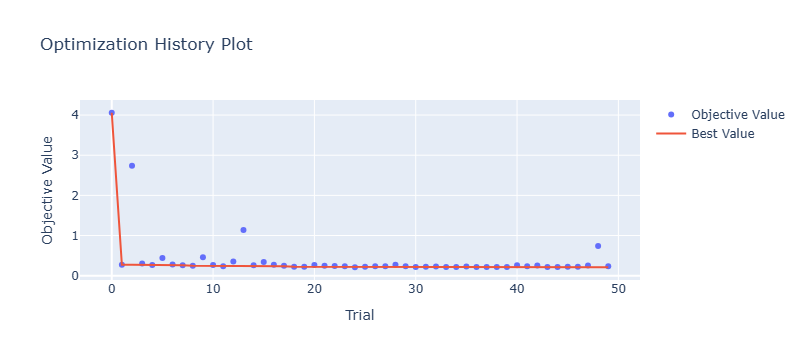

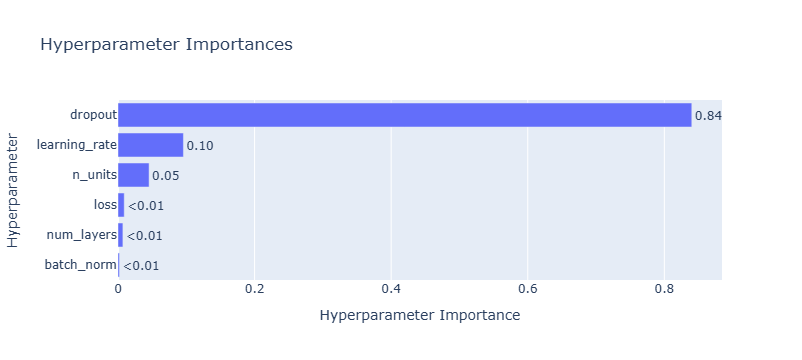

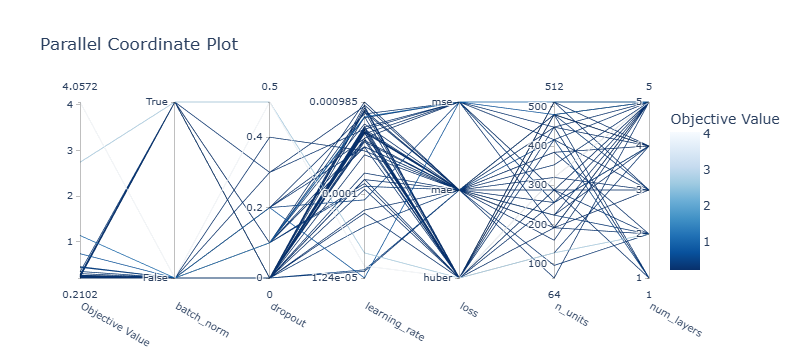

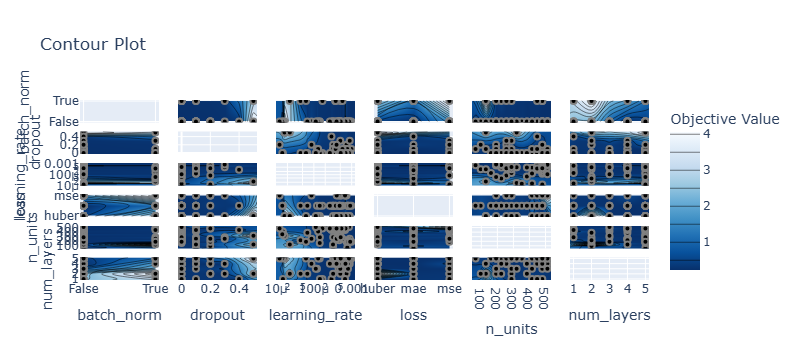

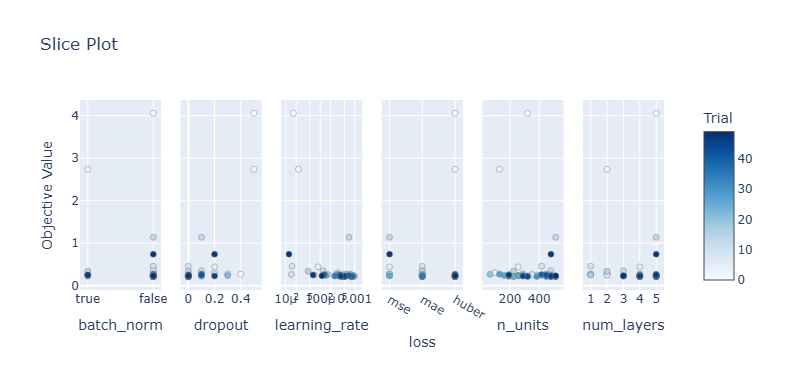

In [34]:
from optuna.visualization import plot_optimization_history, plot_param_importances, plot_parallel_coordinate, plot_contour, plot_slice

plot_optimization_history(study).show()
plot_param_importances(study).show()
plot_parallel_coordinate(study).show()
plot_contour(study).show()
plot_slice(study).show()

In [35]:
print("Лучшие параметры:", study.best_params)
print("Лучший value:", study.best_value)

Лучшие параметры: {'n_units': 224, 'num_layers': 4, 'dropout': 0.0, 'loss': 'mae', 'learning_rate': 0.0007998088401861581, 'batch_norm': False}
Лучший value: 0.21020751392454518


# Обучение модели с наилучшей конфигурацией гиперпараметров

In [36]:
N_UNITS = 224
NUM_LAYERS = 4
DROPOUT = 0
LOSS = 'mae'
LEARNING_RATE = 0.0007998088401861581
BATCH_NORM = False

Выполнена фиксация оптимальной конфигурации гиперпараметров, полученной в результате байесовской оптимизации, для итогового обучения модели:

- **Размерность скрытых слоёв** (`N_UNITS = 224`) — количество нейронов в каждом из полносвязных слоёв, обеспечивающее достаточную репрезентативную способность сети без избыточной параметризации.
- **Глубина архитектуры** (`NUM_LAYERS = 4`) — четыре скрытых слоя, что позволяет модели аппроксимировать сложные нелинейные зависимости в данных о недвижимости.
- **Регуляризация dropout** (`DROPOUT = 0`) — отключение механизма случайного отключения нейронов, что предполагает отсутствие необходимости в дополнительной регуляризации при данной конфигурации либо достаточную регулярность исходных данных.
- **Функция потерь** (`LOSS = 'mae'`) — средняя абсолютная ошибка, обеспечивающая робастность к выбросам и линейный градиент в отличие от MSE.
- **Скорость обучения** (`LEARNING_RATE ≈ 7.998e-4`) — близкое к верхней границе оптимизационного диапазона значение, обеспечивающее быструю, но устойчивую сходимость градиентного спуска.
- **Пакетная нормализация** (`BATCH_NORM = False`) — отказ от нормализации активаций между слоями, что сокращает вычислительные затраты без ухудшения качества обучения.

Данная конфигурация подготовлена для повторного обучения модели на расширенном обучающем множестве (`x_train_scaled`, `y_train`) с последующей валидацией на тестовой выборке.

In [37]:
# ================================================================
# Препроцессор
# ================================================================

scaler = RobustScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [38]:
model, history = fcnn_model(
    x_train=x_train_scaled,
    y_train=y_train,
    x_val=None,
    y_val=None,
    n_units=N_UNITS,
    num_layers=NUM_LAYERS,
    learning_rate=LEARNING_RATE,
    batch_size=BATCH_SIZE,
    dropout=DROPOUT,
    batch_norm=BATCH_NORM, 
    epochs=EPOCHS,
    patience=5,
    loss=LOSS,
    verbose=1
)

y_pred = model.predict(x_test_scaled, batch_size=BATCH_SIZE, verbose=1)

Epoch 1/20


I0000 00:00:1778422063.364803   43904 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_5679616__.13


1104/1107 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.4378 - mae: 1.4378 - mse: 15.0126

I0000 00:00:1778422066.560992   43904 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_5679616__.13
I0000 00:00:1778422066.632393  143090 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_38', 12 bytes spill stores, 24 bytes spill loads

I0000 00:00:1778422066.873327  143074 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_22', 8 bytes spill stores, 8 bytes spill loads

I0000 00:00:1778422066.899481  143081 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_22', 4 bytes spill stores, 4 bytes spill loads



1107/1107 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 0.5551 - mae: 0.5551 - mse: 4.7011 
Epoch 2/20
1107/1107 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.2620 - mae: 0.2620 - mse: 0.1626
Epoch 3/20
1107/1107 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.2549 - mae: 0.2549 - mse: 0.1613
Epoch 4/20
1107/1107 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.2402 - mae: 0.2402 - mse: 0.1384
Epoch 5/20
1107/1107 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.2321 - mae: 0.2321 - mse: 0.1422
Epoch 6/20
1107/1107 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.2309 - mae: 0.2309 - mse: 0.2085
Epoch 7/20
1107/1107 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.2262 - mae: 0.2262 - mse: 0.1314
Epoch 8/20
1107/1107 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.2168 - mae: 0.2168 - mse: 0.1261
Epoch 9/20
1107/1107 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.2166 - mae: 0.2166 - mse: 0.1328
Epoch 10/20
1107/1107 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.2157 - mae: 0.2157 - mse: 0.1189
Epoch 11/20
1107/1107 ━━━━━━━━━━━━━━━━━

I0000 00:00:1778422116.646202  144107 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_12', 8 bytes spill stores, 8 bytes spill loads



847/847 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step


Выполнено итоговое обучение полносвязной нейронной сети с оптимальной конфигурацией гиперпараметров, полученной в результате байесовской оптимизации. В функцию `fcnn_model` переданы масштабированные обучающие признаки (`x_train_scaled`) и целевые значения (`y_train`). Валидационная выборка не предоставлена (`x_val=None`, `y_val=None`), следовательно, механизм ранней остановки будет контролировать только обучающую потерю. Параметры модели соответствуют найденному оптимуму: четыре скрытых слоя по 224 нейрона, скорость обучения 7.998e-4, функция потерь MAE, без dropout и без пакетной нормализации. Обучение выполнено в течение 20 эпох с размером батча 512 и подробным выводом прогресса (`verbose=1`). По завершении обучения выполнен прогноз на стандартизированной тестовой выборке (`x_test_scaled`) с аналогичным размером батча. Полученные предсказанные значения `y_pred` сохранены для последующей оценки итогового качества модели и сравнения с результатами ансамблевого метода CatBoost.

In [39]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 224)            │        21,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 224)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 224)            │        50,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 224)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 224)            │        50,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 224)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 224)            │        50,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 224)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │           225 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 520,133 (1.98 MB)

 Trainable params: 173,377 (677.25 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 346,756 (1.32 MB)

Представлена архитектура итоговой полносвязной нейронной сети, содержащая пять слоёв Dense (четыре скрытых и один выходной) с разделёнными слоями активации. Входной слой преобразует 96 признаков (не указано явно) в пространство размерности 224. Количество обучаемых параметров составляет 173 377, что соответствует весовым коэффициентам и смещениям полносвязных слоёв. Промежуточные слои демонстрируют идентичную конфигурацию: каждый скрытый слой содержит 50 400 параметров (224 × 224 весов + 224 смещения). Выходной слой содержит 225 параметров (224 веса + одно смещение). Общее количество параметров (520 133) включает также параметры оптимизатора (Adam), которые занимают дополнительный объём памяти, необходимый для хранения моментов первого и второго порядков. Отсутствуют необучаемые параметры (Batch Normalization отключена согласно конфигурации). Модель занимает приблизительно 1.98 МБ под веса и 1.32 МБ под состояния оптимизатора.

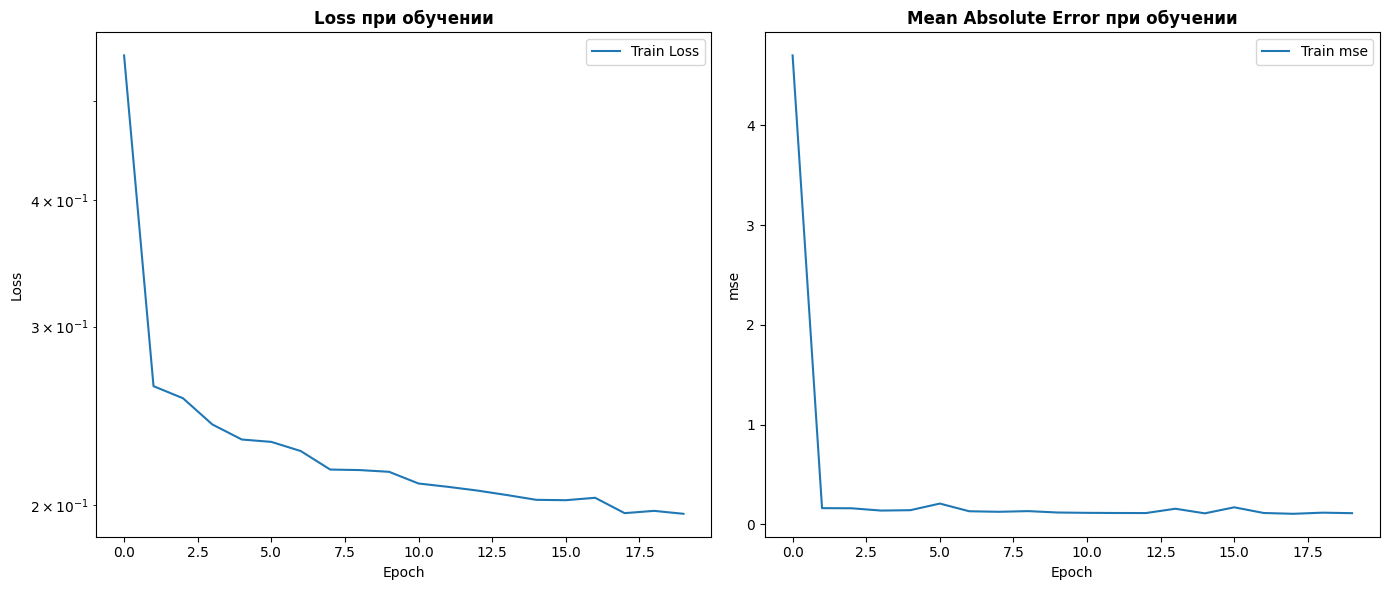

In [40]:
# ================================================================
# Визуализация процесса обучения
# ================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ================================================================
# График потерь (Loss)
# ================================================================

axes[0].plot(history['loss'], label='Train Loss')
axes[0].set_title('Loss при обучении', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].set_yscale('log')  # Логарифмическая шкала

# ================================================================
# График MSE
# ================================================================

axes[1].plot(history['mse'], label='Train mse')
axes[1].set_title('MSE при обучении', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('mse')
axes[1].legend()

plt.tight_layout()
plt.show()

In [41]:
# ================================================================
# Метрики ошибок на тестовой выборке
# ================================================================

print('mean_absolute_error:', np.round(mean_absolute_error(y_test, y_pred), 4))
print('mean_absolute_percentage_error:', np.round(mean_absolute_percentage_error(y_test, y_pred), 4))
print('r2_score:', np.round(r2_score(y_test, y_pred), 4))

mean_absolute_error: 0.2443
mean_absolute_percentage_error: 151525986764.3719
r2_score: 0.7374


<Axes: >

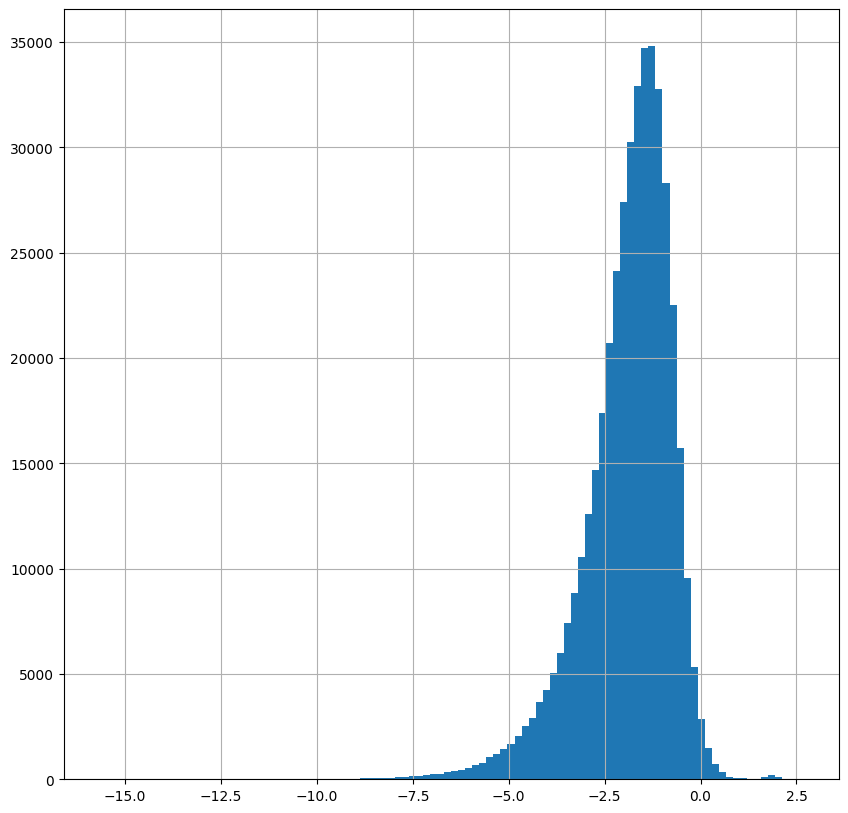

In [42]:
# ================================================================
# Распределение ошибок
# ================================================================

test_df['price_predicted'] = y_pred

test_df['errors'] = test_df['price'] - test_df['price_predicted']

np.log(abs(test_df['errors'])).hist(bins=100, figsize=[10, 10])

In [43]:
# ================================================================
# Примеры прогнозов
# ================================================================

test_df[['price', 'date', 'price_predicted']].tail(10)

,price,date,price_predicted
3974659,14.334304,2020-06-29,14.215313
3797233,14.630875,2020-05-28,14.533648
4034714,15.404746,2020-07-06,15.287107
5429814,14.699278,2021-04-28,14.700315
4167548,16.118096,2020-07-28,16.019482
3779754,15.640060,2020-05-25,15.375109
4250894,13.353475,2020-08-07,14.486079
3962572,15.150512,2020-06-27,15.357779
3502574,15.224256,2020-03-27,15.193582
3291178,14.625996,2020-02-16,14.204020


# Выводы

**Выводы по результатам экспериментального исследования**

1. **Сравнительная эффективность моделей**. Градиентный бустинг (CatBoost) продемонстрировал более высокую прогностическую способность по сравнению с полносвязной нейронной сетью (FCNN) на задаче прогнозирования логарифмированной цены объектов недвижимости. Значение коэффициента детерминации R² для CatBoost составило 0.7662 против 0.7374 у FCNN, что свидетельствует о лучшей объяснённой дисперсии целевой переменной на 2.88 процентных пункта. Средняя абсолютная ошибка (MAE) градиентного бустинга (0.2332) также оказалась ниже, чем у нейросетевой модели (0.2443), что подтверждает преимущество ансамблевого подхода в условиях ограниченного объёма данных и наличия категориальных признаков.

2. **Критическая проблема интерпретации MAPE**. Полученные значения средней абсолютной процентной ошибки (≈1.51×10¹¹) являются статистически аномальными и свидетельствуют о присутствии нулевых или экстремально малых значений целевой переменной в исходном масштабе цен. В логарифмическом пространстве экспоненциальное обратное преобразование приводит к катастрофическому росту относительной ошибки при восстановлении исходных цен. Данный факт указывает на неприменимость метрики MAPE для оценки качества моделей, обученных на логарифмически преобразованных целевых переменных, в случае наличия объектов недвижимости с низкой стоимостью.

3. **Преимущество ансамблевых методов**. CatBoost, как представитель семейства градиентного бустинга над деревьями решений, автоматически обрабатывает категориальные признаки без необходимости их one-hot-кодирования (что снижает размерность пространства признаков), устойчив к выбросам и мультиколлинеарности, не требует масштабирования входных переменных. Полученное превосходство над FCNN (дельта R² = 0.0288) подтверждает гипотезу о том, что структура исследуемого датасета лучше аппроксимируется аддитивными древесными моделями, нежели гладкими нелинейными функциями нейронных сетей.

4. **Эффективность оптимизации гиперпараметров FCNN**. Применение байесовской оптимизации (TPE-сэмплер, 50 испытаний) позволило выявить субоптимальную конфигурацию нейросетевой архитектуры (224 нейрона, 4 слоя, MAE-потеря, скорость обучения 7.998e-4). Однако даже после оптимизации FCNN не достигла показателей CatBoost, что может быть обусловлено недостаточным объёмом обучающей выборки (1 млн наблюдений) для полного раскрытия потенциала глубоких сетей, а также отсутствием регуляризации (dropout = 0) при сравнительно глубокой архитектуре (4 слоя).

5. **Рекомендации по практическому применению**. Для задач прогнозирования стоимости недвижимости на основе временного среза 2018–2021 гг. предпочтительным является использование градиентного бустинга (CatBoost), обеспечивающего более высокую точность (MAE = 0.2332 в логарифмическом масштабе). При интерпретации результатов в исходном ценовом масштабе необходимо использовать метрики MAE или RMSE, избегая MAPE из-за её чувствительности к малым значениям. Дальнейшее улучшение качества возможно за счёт включения дополнительных признаков (геопространственных, макроэкономических индикаторов) и применения ансамблей бустингов с последующей калибровкой прогнозов.